# Preprocessing: pipeline effects on Yelp data

This notebook walks through the same stages as `run_preprocessing.ipynb` and shows **how values look** on raw vs processed data. Histograms use **multiple metrics per figure**; degenerate (single-value) columns are skipped.

**Prerequisite:** Run `run_preprocessing.ipynb` through Stage 7 so Parquet and `column_lineage.json` exist.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import importlib

from src.constants import PROCESSED_DIR
from src.preprocessing.column_lineage import read_column_lineage
from src.spark.load_data import load_dataset
import src.spark.pandas_sample as _pandas_sample_mod
importlib.reload(_pandas_sample_mod)
to_pandas_sample = _pandas_sample_mod.to_pandas_sample
from src.spark.session import create_spark_session

sns.set_style("whitegrid")
%matplotlib inline

In [2]:
spark = create_spark_session("preprocessing_comparison")

TABLE_NAMES = ["business", "review", "user", "checkin", "tip", "photo"]

raw = {name: load_dataset(spark, name) for name in TABLE_NAMES}

processed = {}
all_exist = all((PROCESSED_DIR / n).exists() for n in TABLE_NAMES)
if all_exist:
    for name in TABLE_NAMES:
        processed[name] = spark.read.parquet(str(PROCESSED_DIR / name))
else:
    print("Some processed paths missing - running preprocess_all (run run_preprocessing.ipynb to write Parquet)")
    from src.preprocessing import preprocess_all
    processed = preprocess_all(spark, load_raw=True)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/29 19:43:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/29 19:43:15 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).
26/03/29 19:43:16 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


---
## Pipeline overview (matches `run_preprocessing.ipynb`)

| Stage | Step | Role |
|-------|------|------|
| 1 | Load | Read JSON into Spark |
| 2 | Clean | Nulls, duplicates |
| 3 | Flatten | Nested maps/arrays → columns |
| 4 | Prune | Drop redundant nested fields after flatten |
| 5 | Transform | Parse dates, min–max scale numerics, drop raw `date` strings |
| 6 | Reduce | Optional sampling (default: none) |
| 7 | Write | Parquet + `column_lineage.json` under `artifacts/processed/` |


---
## Stage 1 — Load

JSON datasets read into Spark (`load_dataset`). Row/column volumes are summarized after processing in Stages 3–4.


---
## Stage 2 — Clean

Imputation and duplicate drops on primary keys. Row counts change only when cleaning removes rows.


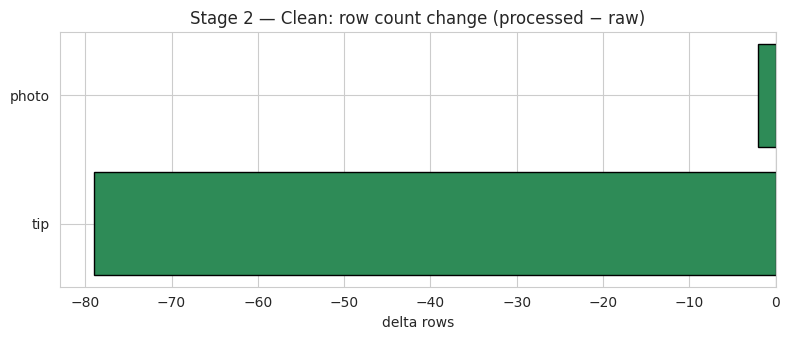

In [3]:
# Build impact_df (needed for Clean plot below and for column/row charts in Stages 3–4)
impact_rows = []
for name in TABLE_NAMES:
    if name not in raw or name not in processed:
        continue
    impact_rows.append(
        {
            "table": name,
            "raw_cols": len(raw[name].columns),
            "proc_cols": len(processed[name].columns),
            "raw_rows": raw[name].count(),
            "proc_rows": processed[name].count(),
        }
    )
impact_df = pd.DataFrame(impact_rows)
impact_df["delta_cols"] = impact_df["proc_cols"] - impact_df["raw_cols"]
impact_df["delta_rows"] = impact_df["proc_rows"] - impact_df["raw_rows"]
# Stage 2 — Clean: row deltas (tips lose duplicate keys, etc.)
fig, ax = plt.subplots(figsize=(8, 3.5))
d = impact_df[impact_df["delta_rows"] != 0].copy()
if len(d):
    ax.barh(d["table"], d["delta_rows"], color="seagreen", edgecolor="black")
    ax.set_title("Stage 2 — Clean: row count change (processed − raw)")
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_xlabel("delta rows")
else:
    ax.text(0.5, 0.5, "No row-count change between raw load and processed Parquet.", ha="center", va="center")
    ax.set_axis_off()
plt.tight_layout()
plt.show()


---
<a id="stage-3--flatten"></a>
## Stage 3 — Flatten

Lineage table, plotting helpers, **schema-width** bars, then flatten-specific bars and processed distributions.


#### Lineage snapshot (`column_lineage.json`)

Written by `run_preprocessing.ipynb` Stage 7. Counts below feed the flatten/prune bar charts in this section and in Stage 4.


In [4]:
lineage = read_column_lineage()
if lineage is None:
    print("No column_lineage.json — run run_preprocessing.ipynb (through Stage 7) to write it.")
else:
    rows = []
    for name in sorted(lineage.keys()):
        info = lineage[name]
        rows.append(
            {
                "table": name,
                "after_clean": info["column_count_after_clean"],
                "after_flatten": info["column_count_after_flatten"],
                "flatten_added_n": len(info["flatten_added_columns"]),
                "pruned_n": len(info["pruned_columns"]),
                "final": info["column_count_final"],
            }
        )
    print(pd.DataFrame(rows).to_string(index=False))


   table  after_clean  after_flatten  flatten_added_n  pruned_n  final
business           14             56               42         3     53
 checkin            2              3                1         0      6
   photo            4              4                0         0      4
  review            9              9                0         0     12
     tip            5              5                0         0      8
    user           22             25                3         2     27


In [5]:
import numpy as np


def degenerate_series(s) -> bool:
    """True if a histogram would collapse to a single bin."""
    s = pd.Series(s).dropna()
    if len(s) <= 1:
        return True
    return bool(s.nunique() <= 1)


def plot_hist_grid(pdf, cols, title, bins=35, max_cols=3):
    """Multi-panel histograms; skips degenerate columns."""
    cols = [c for c in cols if c in pdf.columns]
    usable = [c for c in cols if not degenerate_series(pdf[c])]
    skipped = [c for c in cols if c not in usable]
    if skipped:
        print(f"{title}: skipped degenerate columns: {skipped}")
    if not usable:
        print(f"{title}: no plottable columns (all degenerate or missing).")
        return
    n = len(usable)
    ncols = min(max_cols, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for i, col in enumerate(usable):
        pdf[col].dropna().hist(ax=axes[i], bins=bins, edgecolor="black", alpha=0.75, color="steelblue")
        axes[i].set_title(col)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_ax_feature_dist(ax, s, title: str, max_bar_levels=30):
    """Bar chart of value counts when cardinality is low, else histogram (avoids empty panels after min–max scaling)."""
    s = pd.Series(s).dropna()
    if len(s) == 0:
        ax.text(0.5, 0.5, f"{title}\n(no data)", ha="center", va="center", transform=ax.transAxes)
        return
    nu = int(s.nunique())
    if nu <= max_bar_levels:
        vc = s.value_counts().sort_index()
        vc.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black", width=0.85)
        ax.set_xticklabels([str(x)[:14] for x in vc.index], rotation=45, ha="right")
        ax.set_ylabel("count")
    else:
        s.hist(ax=ax, bins=min(40, max(10, int(np.sqrt(len(s))))), edgecolor="black", alpha=0.75, color="steelblue")
        ax.set_ylabel("frequency")
    ax.set_title(title)


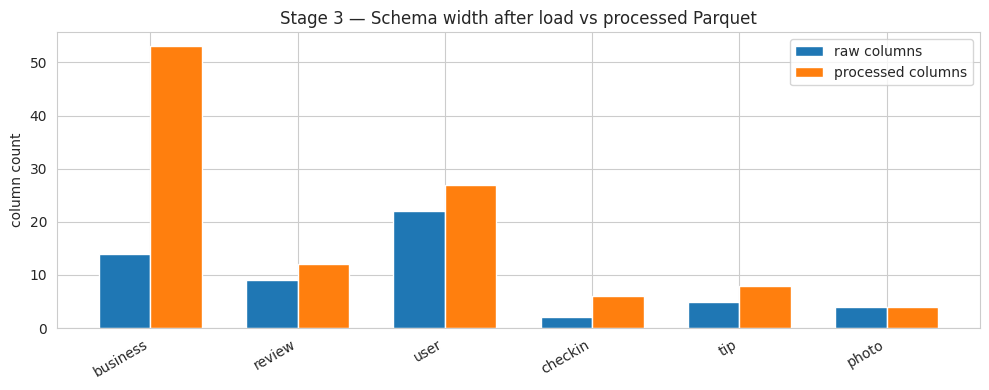

   table  raw_cols  proc_cols  delta_cols
business        14         53          39
  review         9         12           3
    user        22         27           5
 checkin         2          6           4
     tip         5          8           3
   photo         4          4           0


In [6]:
# Schema width: raw vs processed columns (same data as former “Pipeline impact”, left panel)
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(impact_df))
w = 0.35
ax.bar(x - w / 2, impact_df["raw_cols"], w, label="raw columns", color="tab:blue")
ax.bar(x + w / 2, impact_df["proc_cols"], w, label="processed columns", color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels(impact_df["table"], rotation=30, ha="right")
ax.set_ylabel("column count")
ax.legend()
ax.set_title("Stage 3 — Schema width after load vs processed Parquet")
plt.tight_layout()
plt.show()
print(impact_df[["table", "raw_cols", "proc_cols", "delta_cols"]].to_string(index=False))


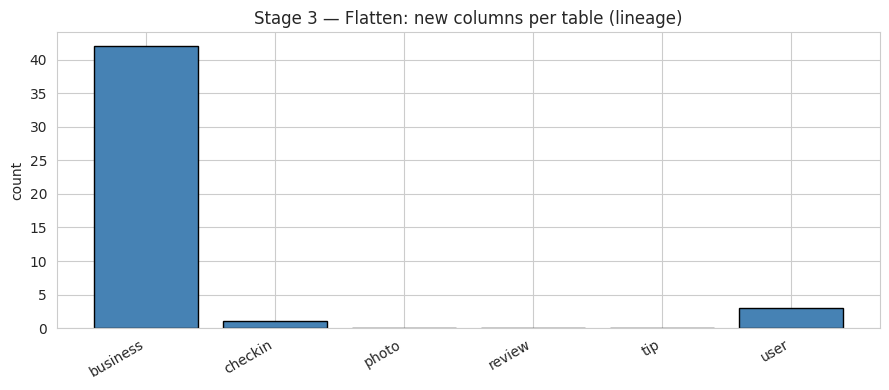

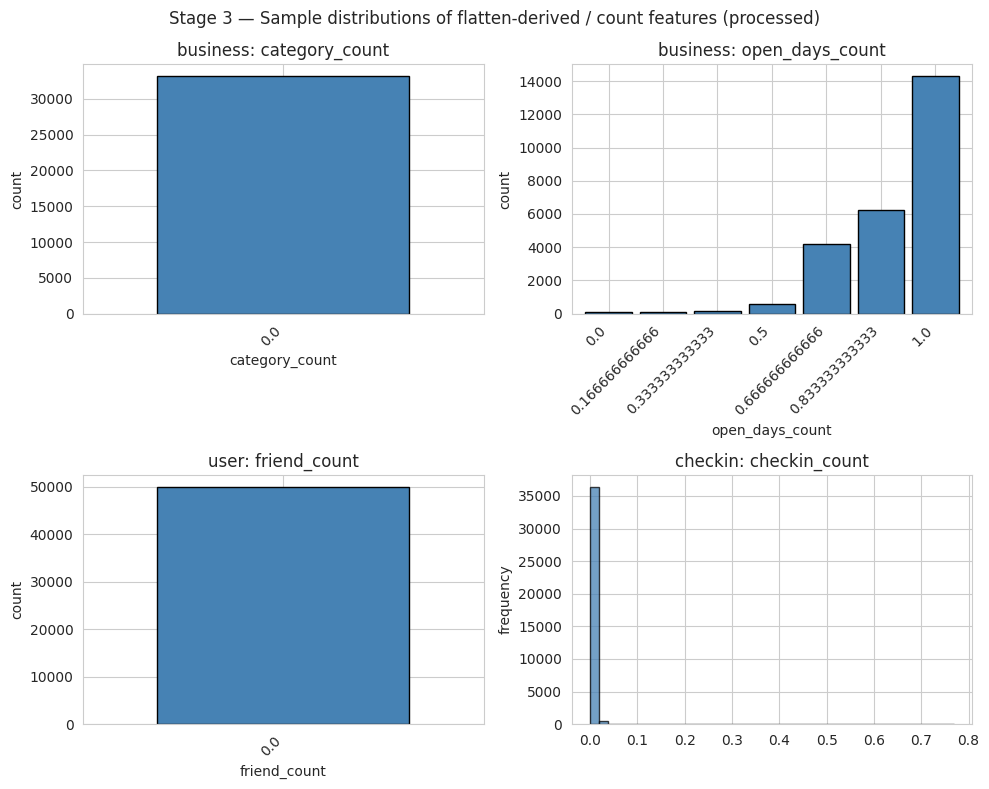

In [7]:
# Stage 3 — Flatten: bar chart + enriched feature distributions (processed Parquet)
if lineage:
    names = sorted(lineage.keys())
    vals = [len(lineage[n]["flatten_added_columns"]) for n in names]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(names, vals, color="steelblue", edgecolor="black")
    ax.set_title("Stage 3 — Flatten: new columns per table (lineage)")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Stage 3 — Sample distributions of flatten-derived / count features (processed)")
specs = [
    ("business", "category_count", 0.22),
    ("business", "open_days_count", 0.2),
    ("user", "friend_count", 0.18),
    ("checkin", "checkin_count", 0.28),
]
for ax, (t, col, frac) in zip(np.array(axes).flat, specs):
    if t not in processed or col not in processed[t].columns:
        ax.set_axis_off()
        continue
    pdf = to_pandas_sample(processed[t].select(col), fraction=frac, columns=[col])
    plot_ax_feature_dist(ax, pdf[col], f"{t}: {col}")
plt.tight_layout()
plt.show()


---
<a id="stage-4--prune"></a>
## Stage 4 — Prune

**Row-volume** bars, then **prune** bar (columns dropped per table).


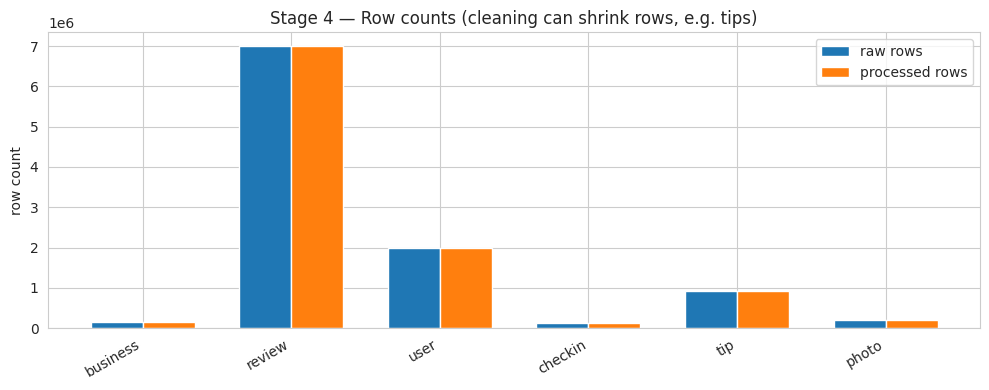

   table  raw_rows  proc_rows  delta_rows
business    150346     150346           0
  review   6990280    6990280           0
    user   1987897    1987897           0
 checkin    131930     131930           0
     tip    908915     908836         -79
   photo    200100     200098          -2


In [8]:
# Row volume: raw vs processed (same data as former “Pipeline impact”, right panel)
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(impact_df))
w = 0.35
ax.bar(x - w / 2, impact_df["raw_rows"], w, label="raw rows", color="tab:blue")
ax.bar(x + w / 2, impact_df["proc_rows"], w, label="processed rows", color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels(impact_df["table"], rotation=30, ha="right")
ax.set_ylabel("row count")
ax.legend()
ax.set_title("Stage 4 — Row counts (cleaning can shrink rows, e.g. tips)")
plt.tight_layout()
plt.show()
print(impact_df[["table", "raw_rows", "proc_rows", "delta_rows"]].to_string(index=False))


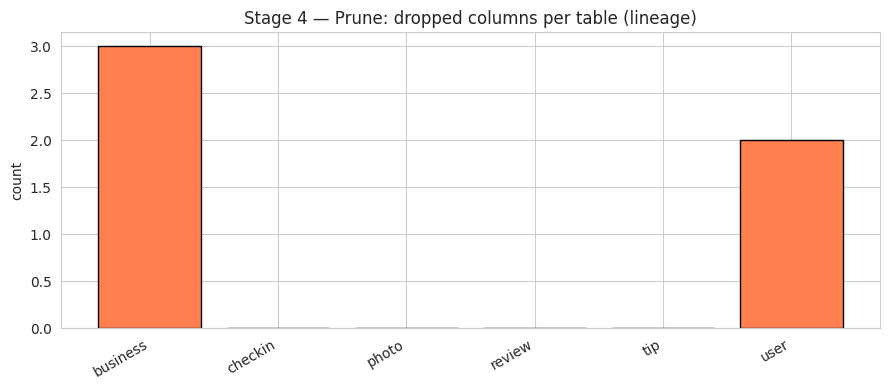

In [9]:
# Stage 4 — Prune: columns removed per table (lineage)
if lineage:
    names = sorted(lineage.keys())
    vals = [len(lineage[n]["pruned_columns"]) for n in names]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(names, vals, color="coral", edgecolor="black")
    ax.set_title("Stage 4 — Prune: dropped columns per table (lineage)")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()


---
## Stage 5 — Transform

Parse dates (`date_parsed`, `date_year`, …). **Min–max** scaling replaces original numerics in place ([`scale_numeric`](../../preprocessing/transform.py)). Below: **one figure per metric** with **raw** (left) and **processed** (right); review/tip also show **year from the raw date string** vs **`date_year`**.


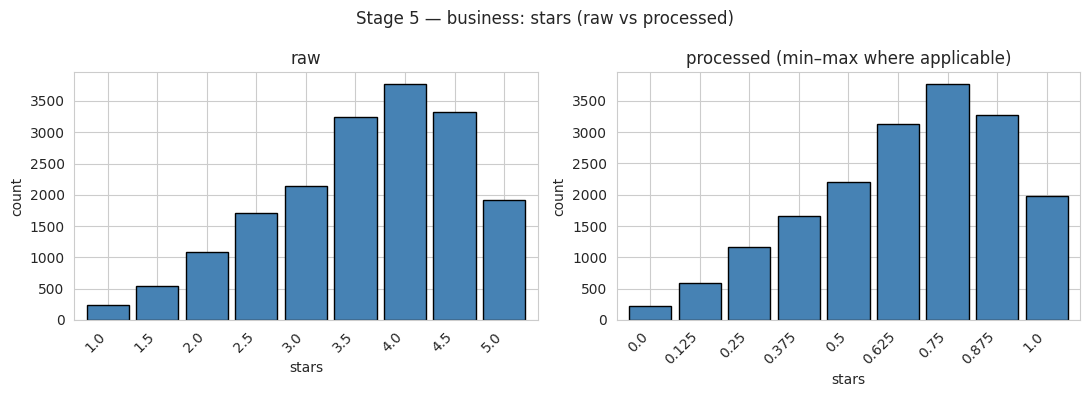

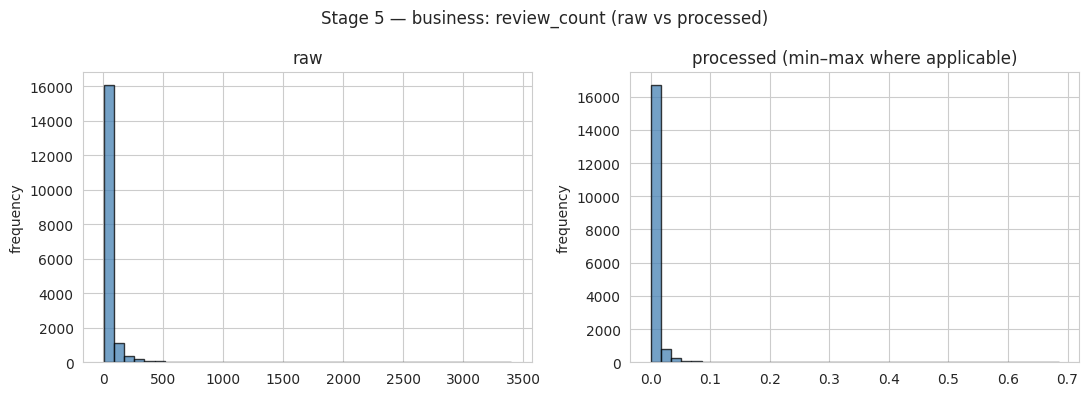

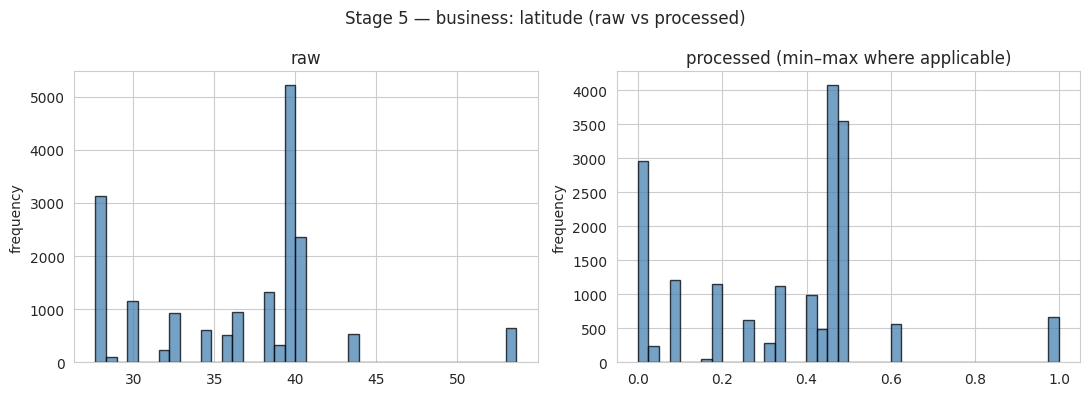

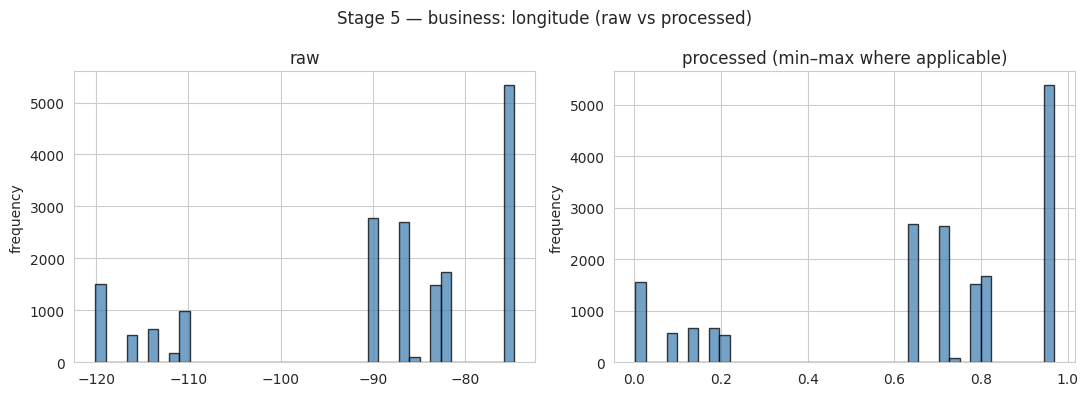

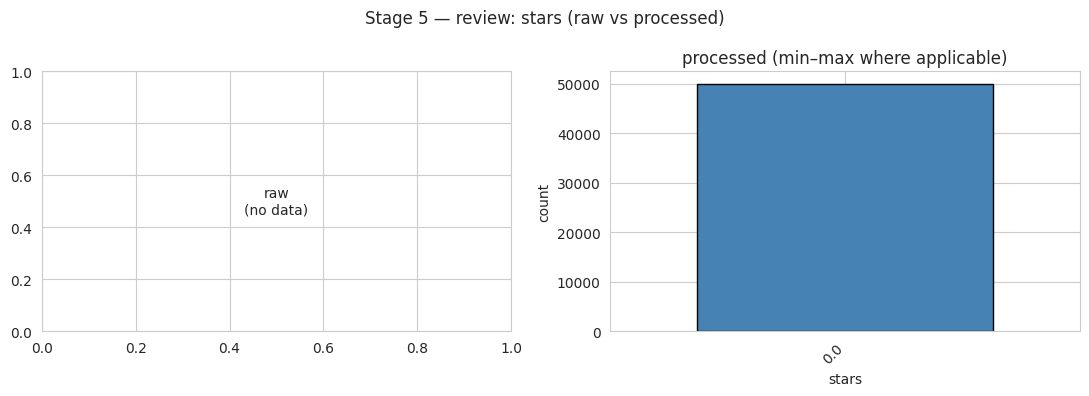

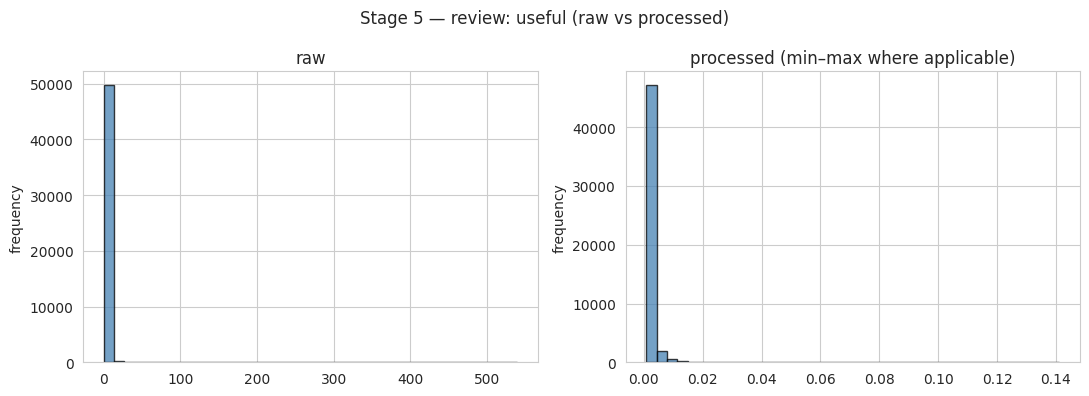

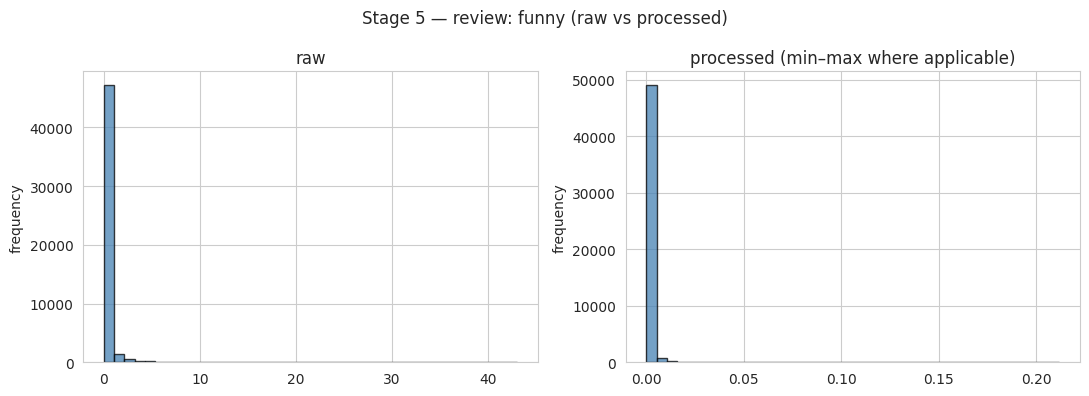

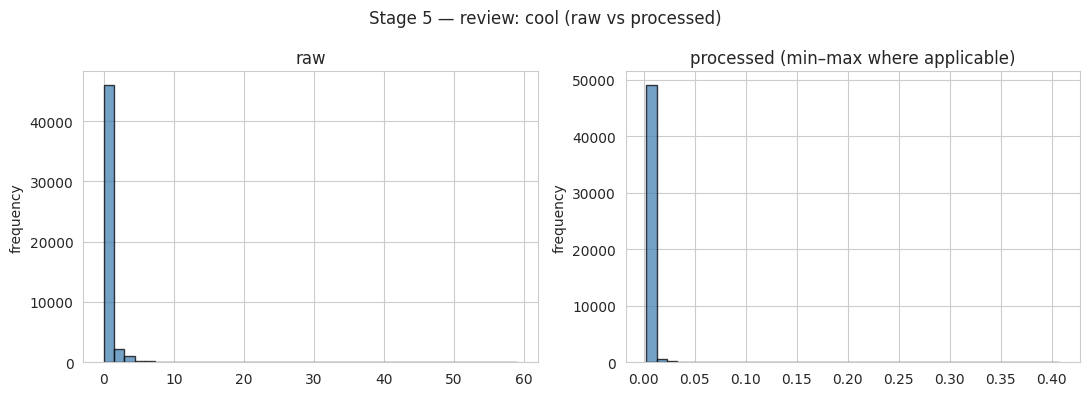

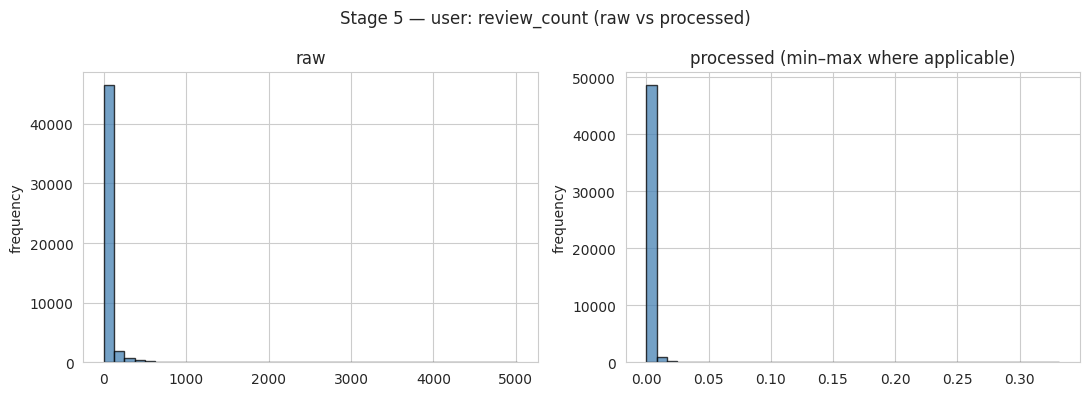

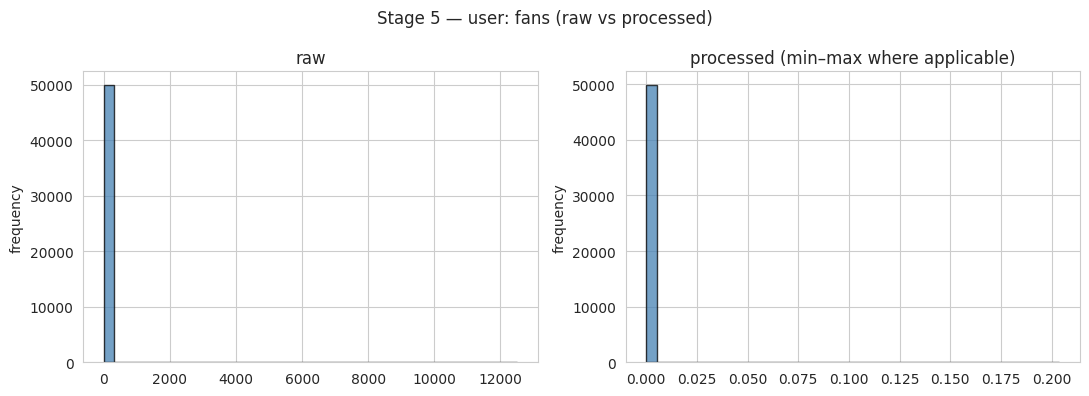

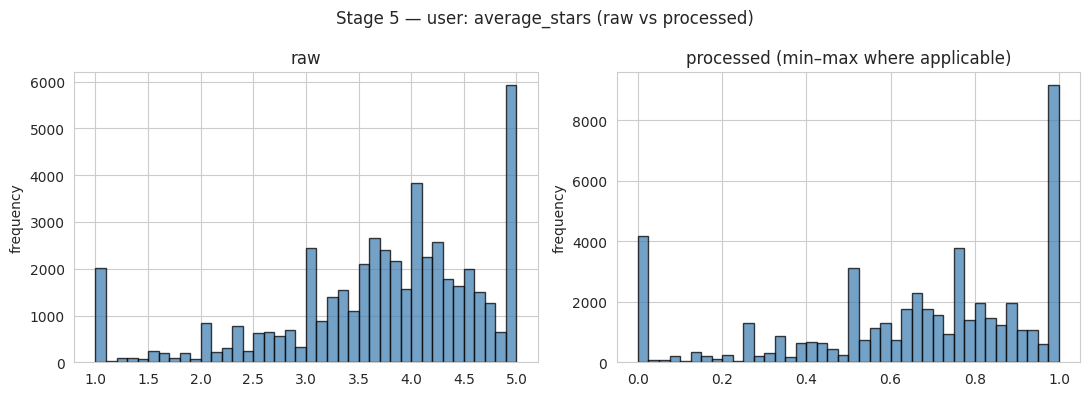

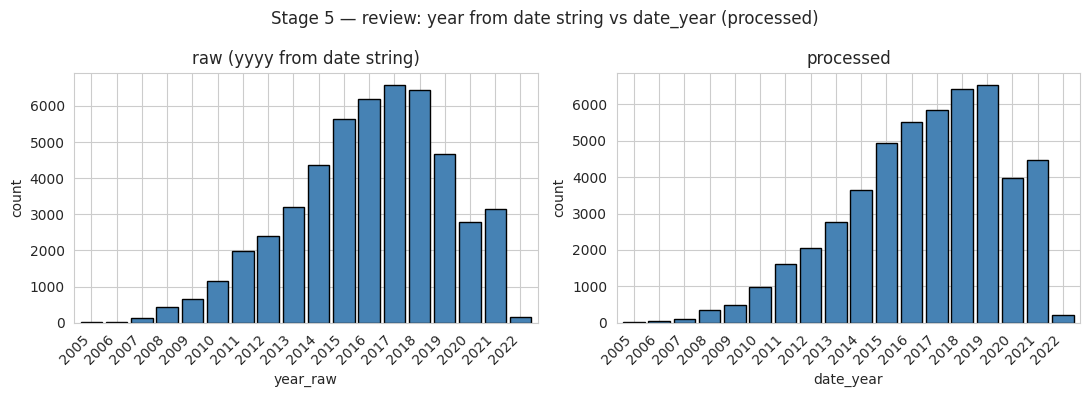

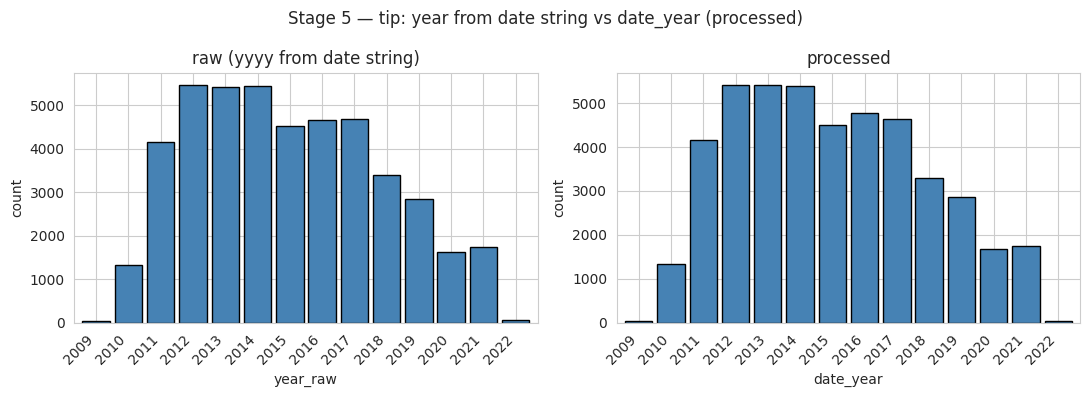

In [10]:
# Stage 5 — Transform: one figure per metric (raw left, processed right)
from pyspark.sql import functions as F


def _paired_raw_proc(rdf, pdf, table: str, cols: list[str], frac: float):
    for col in cols:
        if col not in rdf.columns or col not in pdf.columns:
            continue
        pr = to_pandas_sample(rdf.select(col), fraction=frac, columns=[col])
        pp = to_pandas_sample(pdf.select(col), fraction=frac, columns=[col])
        fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 4))
        fig.suptitle(f"Stage 5 — {table}: {col} (raw vs processed)")
        plot_ax_feature_dist(ax_l, pr[col], "raw")
        plot_ax_feature_dist(ax_r, pp[col], "processed (min–max where applicable)")
        plt.tight_layout()
        plt.show()


cols_b = [c for c in ["stars", "review_count", "latitude", "longitude"] if c in raw["business"].columns and c in processed["business"].columns]
_paired_raw_proc(raw["business"], processed["business"], "business", cols_b, 0.12)

cols_r = [c for c in ["stars", "useful", "funny", "cool"] if c in raw["review"].columns and c in processed["review"].columns]
_paired_raw_proc(raw["review"], processed["review"], "review", cols_r, 0.04)

cols_u = [c for c in ["review_count", "fans", "average_stars"] if c in raw["user"].columns and c in processed["user"].columns]
_paired_raw_proc(raw["user"], processed["user"], "user", cols_u, 0.08)

# Parsed year: raw substring vs processed date_year (review / tip)
for tname in ["review", "tip"]:
    if tname not in raw or tname not in processed:
        continue
    if "date" not in raw[tname].columns or "date_year" not in processed[tname].columns:
        continue
    raw_y = raw[tname].select(F.substring(F.trim(F.col("date")), 1, 4).cast("int").alias("year_raw"))
    pr = to_pandas_sample(raw_y, fraction=0.05, columns=["year_raw"])
    pp = to_pandas_sample(processed[tname].select("date_year"), fraction=0.05, columns=["date_year"])
    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle(f"Stage 5 — {tname}: year from date string vs date_year (processed)")
    plot_ax_feature_dist(ax_l, pr["year_raw"], "raw (yyyy from date string)")
    plot_ax_feature_dist(ax_r, pp["date_year"], "processed")
    plt.tight_layout()
    plt.show()


---
## Stage 6 — Reduce

Default [`sample_fraction`](../../preprocessing/config.py) is `None` — no downsampling unless you configure it.


---
## Stage 7 — Write

Outputs: Parquet under `artifacts/processed/<table>/` and `artifacts/processed/column_lineage.json` (same folder as in `src.constants.PROCESSED_DIR`).


---
## Run summary



In [11]:
print("Run summary (rows × columns):")
for name in TABLE_NAMES:
    if name in raw and name in processed:
        r, p = raw[name].count(), processed[name].count()
        cr, cp = len(raw[name].columns), len(processed[name].columns)
        print(f"  {name}: rows {r} -> {p}, columns {cr} -> {cp}")


Run summary (rows × columns):
  business: rows 150346 -> 150346, columns 14 -> 53


  review: rows 6990280 -> 6990280, columns 9 -> 12


  user: rows 1987897 -> 1987897, columns 22 -> 27
  checkin: rows 131930 -> 131930, columns 2 -> 6


  tip: rows 908915 -> 908836, columns 5 -> 8
  photo: rows 200100 -> 200098, columns 4 -> 4
